### Assignment No. 8

#### Name : Shreyas Babar
#### Roll no. : EN23107002
#### Class : AI(A)-C

In [18]:
import pandas as pd
import numpy as np

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt

In [19]:
import pandas as pd

data = {
"user_id":[
101,101,101,102,102,102,103,103,103,104,104,104,105,105,105,
106,106,106,107,107,107,108,108,108,109,109,109,110,110,110
],

"product":[
"Laptop","Headphones","Smart Watch",
"Laptop","Bluetooth Speaker","Power Bank",
"Mobile Cover","Smart Watch","Power Bank",
"Laptop","Mobile Cover","Bluetooth Speaker",
"Headphones","Power Bank","Smart Watch",
"Wireless Headphones","Bluetooth Speaker","Smart Watch",
"Laptop","Wireless Mouse","Keyboard",
"Power Bank","Mobile Cover","Bluetooth Speaker",
"Smart Watch","Laptop","Headphones",
"Bluetooth Speaker","Power Bank","Mobile Cover"
],

"rating":[
5,4,4,
4,5,4,
3,4,4,
5,3,4,
4,3,5,
5,4,4,
3,4,5,
4,5,3,
4,5,4,
3,4,5
]
}

df = pd.DataFrame(data)

df

,user_id,product,rating
0,101,Laptop,5
1,101,Headphones,4
2,101,Smart Watch,4
3,102,Laptop,4
4,102,Bluetooth Speaker,5
5,102,Power Bank,4
6,103,Mobile Cover,3
7,103,Smart Watch,4
8,103,Power Bank,4
9,104,Laptop,5


In [20]:
user_item_matrix = df.pivot_table(index="user_id",
                                  columns="product",
                                  values="rating").fillna(0)

user_item_matrix

product,Bluetooth Speaker,Headphones,Keyboard,Laptop,Mobile Cover,Power Bank,Smart Watch,Wireless Headphones,Wireless Mouse
user_id,,,,,,,,,
101,0.0,4.0,0.0,5.0,0.0,0.0,4.0,0.0,0.0
102,5.0,0.0,0.0,4.0,0.0,4.0,0.0,0.0,0.0
103,0.0,0.0,0.0,0.0,3.0,4.0,4.0,0.0,0.0
104,4.0,0.0,0.0,5.0,3.0,0.0,0.0,0.0,0.0
105,0.0,4.0,0.0,0.0,0.0,3.0,5.0,0.0,0.0
106,4.0,0.0,0.0,0.0,0.0,0.0,4.0,5.0,0.0
107,0.0,0.0,5.0,3.0,0.0,0.0,0.0,0.0,4.0
108,3.0,0.0,0.0,0.0,5.0,4.0,0.0,0.0,0.0
109,0.0,4.0,0.0,5.0,0.0,0.0,4.0,0.0,0.0


In [21]:
user_similarity = cosine_similarity(user_item_matrix)

user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_item_matrix.index,
    columns=user_item_matrix.index
)

user_similarity_df

user_id,101,102,103,104,105,106,107,108,109,110
user_id,,,,,,,,,,
101,1.000000,0.350877,0.330972,0.468293,0.674342,0.280702,0.280976,0.000000,1.000000,0.000000
102,0.350877,1.000000,0.330972,0.749269,0.224781,0.350877,0.224781,0.580683,0.350877,0.580683
103,0.330972,0.330972,1.000000,0.198777,0.706762,0.330972,0.000000,0.684675,0.330972,0.684675
104,0.468293,0.749269,0.198777,1.000000,0.000000,0.299707,0.300000,0.540000,0.468293,0.540000
105,0.674342,0.224781,0.706762,0.000000,1.000000,0.374634,0.000000,0.240000,0.674342,0.240000
106,0.280702,0.350877,0.330972,0.299707,0.374634,1.000000,0.000000,0.224781,0.280702,0.224781
107,0.280976,0.224781,0.000000,0.300000,0.000000,0.000000,1.000000,0.000000,0.280976,0.000000
108,0.000000,0.580683,0.684675,0.540000,0.240000,0.224781,0.000000,1.000000,0.000000,1.000000
109,1.000000,0.350877,0.330972,0.468293,0.674342,0.280702,0.280976,0.000000,1.000000,0.000000


In [22]:
kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(user_item_matrix)

user_item_matrix["Cluster"] = clusters

user_item_matrix

product,Bluetooth Speaker,Headphones,Keyboard,Laptop,Mobile Cover,Power Bank,Smart Watch,Wireless Headphones,Wireless Mouse,Cluster
user_id,,,,,,,,,,
101,0.0,4.0,0.0,5.0,0.0,0.0,4.0,0.0,0.0,2
102,5.0,0.0,0.0,4.0,0.0,4.0,0.0,0.0,0.0,0
103,0.0,0.0,0.0,0.0,3.0,4.0,4.0,0.0,0.0,1
104,4.0,0.0,0.0,5.0,3.0,0.0,0.0,0.0,0.0,0
105,0.0,4.0,0.0,0.0,0.0,3.0,5.0,0.0,0.0,2
106,4.0,0.0,0.0,0.0,0.0,0.0,4.0,5.0,0.0,0
107,0.0,0.0,5.0,3.0,0.0,0.0,0.0,0.0,4.0,0
108,3.0,0.0,0.0,0.0,5.0,4.0,0.0,0.0,0.0,1
109,0.0,4.0,0.0,5.0,0.0,0.0,4.0,0.0,0.0,2


In [23]:
def recommend_products(user_id, top_n=5):
    
    similar_users = user_similarity_df[user_id].sort_values(ascending=False)[1:3]

    similar_users_ids = similar_users.index

    recommended_products = df[df["user_id"].isin(similar_users_ids)]["product"].value_counts()

    return recommended_products.head(top_n)

In [24]:
recommend_products(105)

product
Smart Watch     2
Mobile Cover    1
Power Bank      1
Laptop          1
Headphones      1
Name: count, dtype: int64

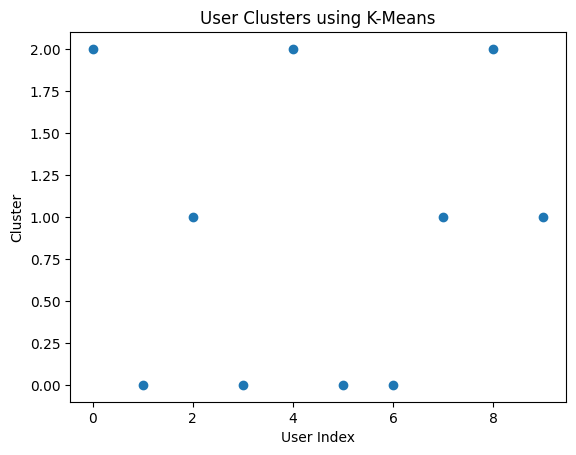

In [25]:
plt.scatter(range(len(clusters)), clusters)

plt.title("User Clusters using K-Means")
plt.xlabel("User Index")
plt.ylabel("Cluster")

plt.show()

In [29]:
from sklearn.metrics import silhouette_score

score = silhouette_score(x, labels)
print(score)

NameError: name 'x' is not defined

In [26]:
da = {
    'User': ['U1','U1','U1','U2','U2','U3','U3','U4'],
    'Product': ['P1','P2','P3','P1','P3','P2','P4','P1'],
    'Rating': [5,4,3,4,5,2,5,3]
}

d = pd.DataFrame(da)
matrix = d.pivot_table(index='User', columns='Product', values='Rating').fillna(0)

In [27]:
matrix

Product,P1,P2,P3,P4
User,,,,
U1,5.0,4.0,3.0,0.0
U2,4.0,0.0,5.0,0.0
U3,0.0,2.0,0.0,5.0
U4,3.0,0.0,0.0,0.0
